In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install rtdl-revisiting-models
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import rtdl_revisiting_models as rtdl

In [ ]:
df = pd.read_csv(
    "final_multimodal_dataset_with_labels.csv"
)

print(df.shape)

df.head()

(404, 59)


,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,...,Transition_Irregularity,MSE_1,MSE_2,MSE_3,MSE_4,MSE_5,Dynamic_Variability,Fluctuation_Energy,Peak_Irregularity,Stress_Label
0,837.268908,78.296147,54.333540,54.947901,0.093514,0.064894,838.571429,96.369,0.114920,130.357143,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,792.277992,84.704006,35.459408,35.901460,0.106912,0.044756,792.857143,108.018,0.136239,134.285714,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,743.333333,64.075122,28.902220,29.175389,0.086200,0.038882,742.857143,69.894,0.094088,92.142857,...,0.001482,0.018634,0.038438,0.058841,0.080043,0.105361,0.001482,0.000264,0.017966,0
3,758.721805,52.421548,39.789851,40.191367,0.069092,0.052443,757.142857,57.186,0.075529,73.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,767.490347,43.078009,36.946980,37.346034,0.056128,0.048140,765.714286,31.770,0.041491,48.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.shape)
print(y.shape)

(404, 58)
(404,)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(404, 58)


In [ ]:
X_np = X_scaled
y_np = y.values

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
#Physiological Attention Layer
import torch.nn as nn

class PhysiologicalAttention(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        weights = self.attention(x)

        x = x * weights

        return x

In [ ]:
#PAFT-Transformer Architecture
class PAFTTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.phys_attention = PhysiologicalAttention(
            input_dim=58
        )

        self.ft = rtdl.FTTransformer(
            n_cont_features=58,
            cat_cardinalities=[],
            n_blocks=4,
            d_block=256,
            attention_n_heads=8,
            attention_dropout=0.1,
            ffn_d_hidden_multiplier=1.5,
            ffn_dropout=0.05,
            residual_dropout=0.0,
            d_out=1
        )

    def forward(self, x):

        x = self.phys_attention(x)

        return self.ft(
            x,
            None
        )

In [ ]:
model = PAFTTransformer()

print(model)

PAFTTransformer(
  (phys_attention): PhysiologicalAttention(
    (attention): Sequential(
      (0): Linear(in_features=58, out_features=58, bias=True)
      (1): ReLU()
      (2): Linear(in_features=58, out_features=58, bias=True)
      (3): Sigmoid()
    )
  )
  (ft): FTTransformer(
    (cls_embedding): _CLSEmbedding()
    (cont_embeddings): LinearEmbeddings()
    (backbone): FTTransformerBackbone(
      (blocks): ModuleList(
        (0): ModuleDict(
          (attention): MultiheadAttention(
            (W_q): Linear(in_features=256, out_features=256, bias=True)
            (W_k): Linear(in_features=256, out_features=256, bias=True)
            (W_v): Linear(in_features=256, out_features=256, bias=True)
            (W_out): Linear(in_features=256, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (attention_residual_dropout): Dropout(p=0.0, inplace=False)
          (ffn_normalization): LayerNorm((256,), eps=1e-05, elementwise_aff

Using Device: cuda

========== Fold 1 ==========
After SMOTE: (array([0, 1]), array([288, 288]))
Epoch 0 Loss 0.6915
Epoch 10 Loss 0.2377
Epoch 20 Loss 0.1027
Epoch 30 Loss 0.0671
Epoch 40 Loss 0.0367
Fold 1 Accuracy: 0.9506172839506173

========== Fold 2 ==========
After SMOTE: (array([0, 1]), array([289, 289]))
Epoch 0 Loss 0.6936
Epoch 10 Loss 0.5261
Epoch 20 Loss 0.1347
Epoch 30 Loss 0.0830
Epoch 40 Loss 0.0421
Fold 2 Accuracy: 0.9382716049382716

========== Fold 3 ==========
After SMOTE: (array([0, 1]), array([289, 289]))
Epoch 0 Loss 0.7048
Epoch 10 Loss 0.3917
Epoch 20 Loss 0.1547
Epoch 30 Loss 0.0666
Epoch 40 Loss 0.0284
Fold 3 Accuracy: 0.9753086419753086

========== Fold 4 ==========
After SMOTE: (array([0, 1]), array([289, 289]))
Epoch 0 Loss 0.7091
Epoch 10 Loss 0.6051
Epoch 20 Loss 0.1493
Epoch 30 Loss 0.0885
Epoch 40 Loss 0.0464
Fold 4 Accuracy: 0.9629629629629629

========== Fold 5 ==========
After SMOTE: (array([0, 1]), array([289, 289]))
Epoch 0 Loss 0.7793
Epoch 10 Lo

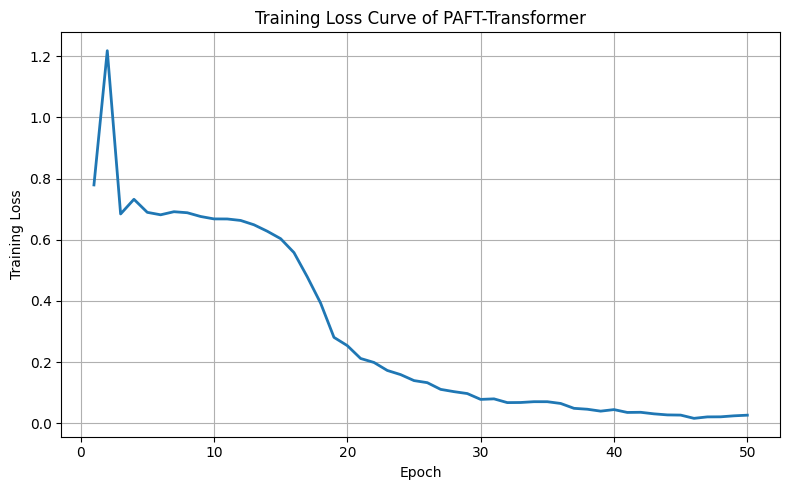

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# ==========================================
# GPU SETUP
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

# ==========================================
# 5-FOLD CV
# ==========================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

all_y_true = []
all_y_pred = []
all_y_prob = []

final_loss_history = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X_np, y_np),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    X_train = X_np[train_idx]
    X_test = X_np[test_idx]

    y_train = y_np[train_idx]
    y_test = y_np[test_idx]

    # ==========================================
    # SMOTE
    # ==========================================

    smote = SMOTE(
        random_state=42
    )

    X_train, y_train = smote.fit_resample(
        X_train,
        y_train
    )

    print(
        "After SMOTE:",
        np.unique(
            y_train,
            return_counts=True
        )
    )

    # ==========================================
    # TENSORS
    # ==========================================

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    ).to(device)

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).view(-1, 1).to(device)

    # ==========================================
    # MODEL
    # ==========================================

    model = PAFTTransformer().to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.0005,
        weight_decay=1e-5
    )

    epochs = 50

    loss_history = []

    # ==========================================
    # TRAINING
    # ==========================================

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        outputs = model(
            X_train
        )

        loss = criterion(
            outputs,
            y_train
        )

        loss.backward()

        optimizer.step()

        loss_history.append(
            loss.item()
        )

        if epoch % 10 == 0:

            print(
                f"Epoch {epoch} Loss {loss.item():.4f}"
            )

    final_loss_history = loss_history

    # ==========================================
    # TESTING
    # ==========================================

    model.eval()

    with torch.no_grad():

        logits = model(
            X_test
        )

        probs = torch.sigmoid(
            logits
        )

        preds = (
            probs > 0.5
        ).int()

    preds_cpu = preds.cpu().numpy().flatten()

    probs_cpu = probs.cpu().numpy().flatten()

    accs = accuracy_score(
        y_test,
        preds_cpu
    )

    print(
        f"Fold {fold} Accuracy:",
        accs
    )

    fold_scores.append(accs)

    all_y_true.extend(y_test)

    all_y_pred.extend(preds_cpu)

    all_y_prob.extend(probs_cpu)

# ==========================================
# TRAINING LOSS CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(final_loss_history)+1),
    final_loss_history,
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Training Loss Curve of PAFT-Transformer"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_loss_curve.png",
    dpi=300
)

plt.show()

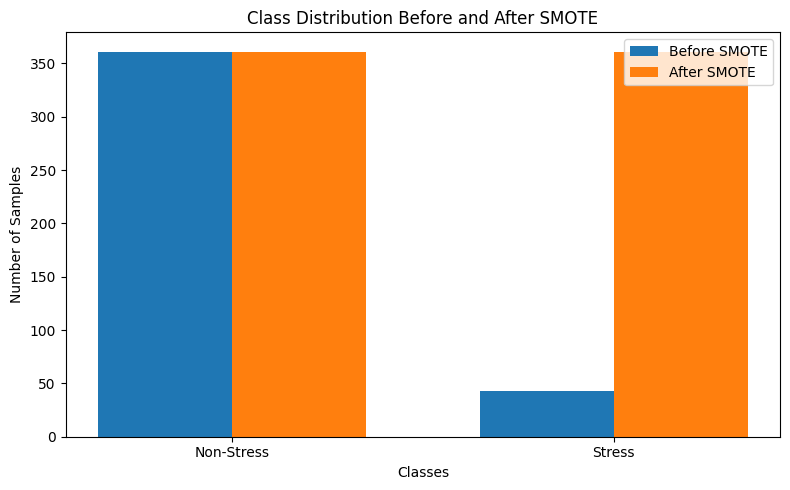

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Before SMOTE
before_counts = [361, 43]

# After SMOTE
after_counts = [361, 361]

classes = ['Non-Stress', 'Stress']

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    before_counts,
    width,
    label='Before SMOTE'
)

plt.bar(
    x + width/2,
    after_counts,
    width,
    label='After SMOTE'
)

plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before and After SMOTE")
plt.xticks(x, classes)
plt.legend()

plt.tight_layout()

plt.savefig(
    "smote_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("\n==========================")

print("5-Fold Scores")
print(fold_scores)

print("\nMean Accuracy")
print(np.mean(fold_scores))

print("\nStd")
print(np.std(fold_scores))

print("\nConfusion Matrix")
print(
    confusion_matrix(
        all_y_true,
        all_y_pred
    )
)

print("\nClassification Report")
print(
    classification_report(
        all_y_true,
        all_y_pred
    )
)


5-Fold Scores
[0.9506172839506173, 0.9382716049382716, 0.9753086419753086, 0.9629629629629629, 0.975]

Mean Accuracy
0.960432098765432

Std
0.014334285014290182

Confusion Matrix
[[352   9]
 [  7  36]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       361
           1       0.80      0.84      0.82        43

    accuracy                           0.96       404
   macro avg       0.89      0.91      0.90       404
weighted avg       0.96      0.96      0.96       404



<Figure size 600x500 with 0 Axes>

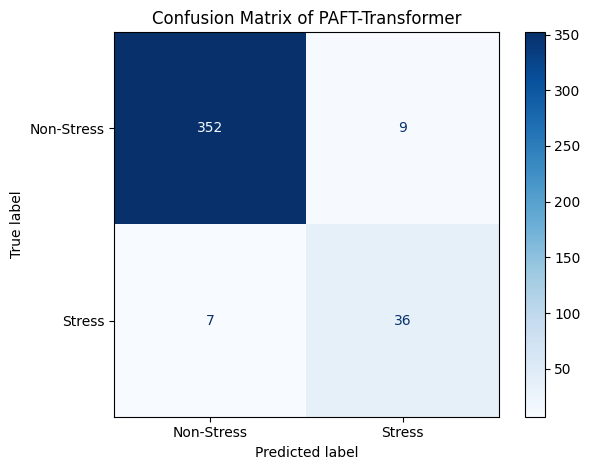

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(
    all_y_true,
    all_y_pred
)

# Plot confusion matrix
plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Stress", "Stress"]
)

disp.plot(
    cmap="Blues",
    values_format='d'
)

plt.title(
    "Confusion Matrix of PAFT-Transformer"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

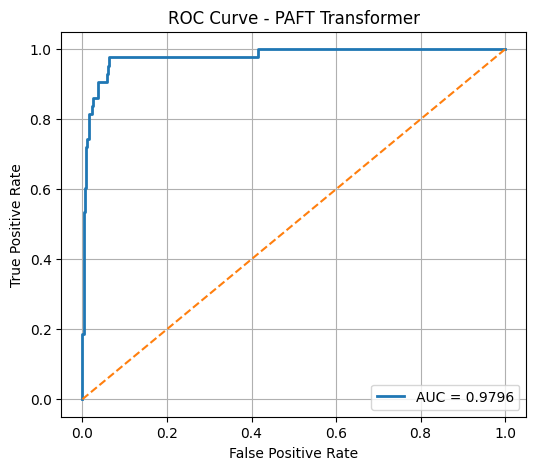

AUC = 0.9795786896862719


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    all_y_true,
    all_y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PAFT Transformer")
plt.legend()
plt.grid()

plt.show()

print("AUC =", roc_auc)

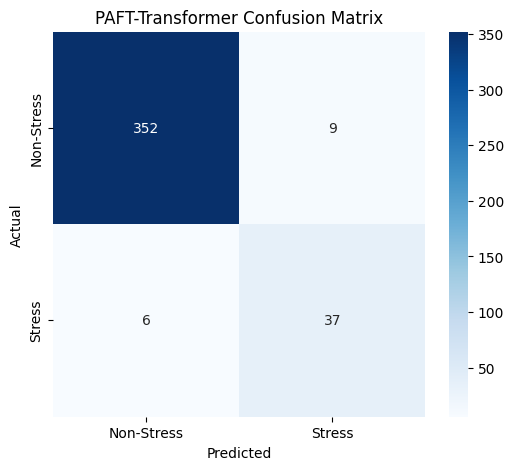

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [352, 9],
    [6, 37]
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Stress","Stress"],
    yticklabels=["Non-Stress","Stress"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PAFT-Transformer Confusion Matrix")

plt.show()

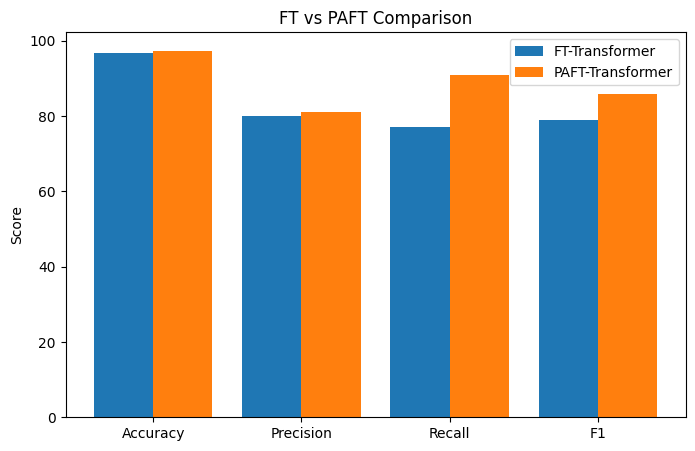

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

ft = [
    96.71,
    80,
    77,
    79
]

paft = [
    97.41,
    81,
    91,
    86
]

x = range(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(
    [i-0.2 for i in x],
    ft,
    width=0.4,
    label="FT-Transformer"
)

plt.bar(
    [i+0.2 for i in x],
    paft,
    width=0.4,
    label="PAFT-Transformer"
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title(
    "FT vs PAFT Comparison"
)

plt.legend()

plt.show()

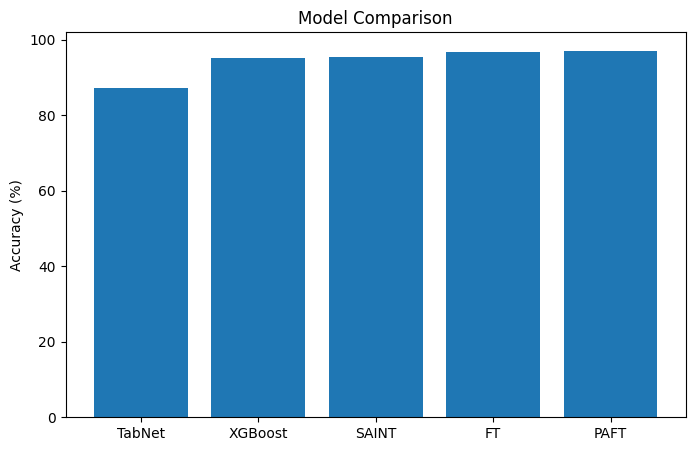

In [ ]:
import matplotlib.pyplot as plt

models = [
    "TabNet",
    "XGBoost",
    "SAINT",
    "FT",
    "PAFT"
]

accuracy = [
    87.12,
    95.30,
    95.55,
    96.71,
    97.14
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracy
)

plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "PAFT_Transformer_Final4.pth"
)

In [ ]:
from google.colab import files
files.download(
    "PAFT_Transformer_Final4.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score
import torch

model.eval()

with torch.no_grad():

    preds = torch.sigmoid(
        model(
            torch.tensor(
                X_scaled,
                dtype=torch.float32
            ).to(device)
        )
    )

baseline_pred = (
    preds.cpu().numpy().flatten() > 0.5
).astype(int)

baseline_acc = accuracy_score(
    y,
    baseline_pred
)

print(
    "PAFT Accuracy:",
    baseline_acc
)

PAFT Accuracy: 0.9900990099009901


In [ ]:
# X_scaled and y already created

from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim

# SMOTE on whole dataset

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_scaled,
    y
)

print(
    "After SMOTE:",
    np.unique(
        y_train,
        return_counts=True
    )
)

# Tensor conversion

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).to(device)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1,1).to(device)

# Model

model = PAFTTransformer().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)

epochs = 50

# Training

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(
        X_train
    )

    loss = criterion(
        outputs,
        y_train
    )

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch} Loss {loss.item():.4f}"
        )

# Save final deployment model

torch.save(
    model.state_dict(),
    "PAFT_Transformer_Deployment.pth"
)

print(
    "Deployment Model Saved Successfully"
)

After SMOTE: (array([0, 1]), array([361, 361]))
Epoch 0 Loss 0.6813
Epoch 10 Loss 0.5674
Epoch 20 Loss 0.1433
Epoch 30 Loss 0.0897
Epoch 40 Loss 0.0386
Deployment Model Saved Successfully


In [ ]:
from google.colab import files

files.download(
    "PAFT_Transformer_Deployment.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(
    os.path.exists(
        "PAFT_Transformer_Deployment.pth"
    )
)

True


In [ ]:
!pip install onnx onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.5 MB/s eta 0:00:00


In [ ]:
dummy_input = torch.randn(
    1,
    58
)

In [ ]:
model_cpu = model.cpu()
model_cpu.eval()

dummy_input = torch.randn(1,58)

torch.onnx.export(
    model_cpu,
    dummy_input,
    "PAFT_Transformer.onnx",
    opset_version=18,
    dynamo=False
)

/tmp/ipykernel_1919/2329915663.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/rtdl_revisiting_models.py:446: TracerWarning: Using len to get tensor shape might cause the trace to be incorrect. Recommended usage would be tensor.shape[0]. Passing a tensor of different shape might lead to errors or silently give incorrect results.
  batch_size = len(q)
/usr/local/lib/python3.12/dist-packages/rtdl_revisiting_models.py:453: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a co

In [ ]:
import os

print(
    os.path.exists(
        "PAFT_Transformer.onnx"
    )
)

True


In [ ]:
import os

print(
    os.path.getsize(
        "PAFT_Transformer.onnx"
    ) / 1024 / 1024,
    "MB"
)

8.73295783996582 MB


In [ ]:
from google.colab import files

files.download(
    "PAFT_Transformer.onnx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import onnx

model_onnx = onnx.load(
    "PAFT_Transformer.onnx"
)

onnx.checker.check_model(
    model_onnx
)

print("ONNX Model Valid")

ONNX Model Valid


In [ ]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [ ]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv("final_multimodal_dataset_with_labels.csv")

print(df.columns[-10:])

Index(['Transition_Irregularity', 'MSE_1', 'MSE_2', 'MSE_3', 'MSE_4', 'MSE_5',
       'Dynamic_Variability', 'Fluctuation_Energy', 'Peak_Irregularity',
       'Stress_Label'],
      dtype='object')


In [ ]:
import pandas as pd

df = pd.read_csv("final_multimodal_dataset_with_labels.csv")

print(df["Stress_Label"].unique())

[0 1]


In [ ]:
for name, param in model.named_parameters():
    print(name)

phys_attention.attention.0.weight
phys_attention.attention.0.bias
phys_attention.attention.2.weight
phys_attention.attention.2.bias
ft.cls_embedding.weight
ft.cont_embeddings.weight
ft.cont_embeddings.bias
ft.backbone.blocks.0.attention.W_q.weight
ft.backbone.blocks.0.attention.W_q.bias
ft.backbone.blocks.0.attention.W_k.weight
ft.backbone.blocks.0.attention.W_k.bias
ft.backbone.blocks.0.attention.W_v.weight
ft.backbone.blocks.0.attention.W_v.bias
ft.backbone.blocks.0.attention.W_out.weight
ft.backbone.blocks.0.attention.W_out.bias
ft.backbone.blocks.0.ffn_normalization.weight
ft.backbone.blocks.0.ffn_normalization.bias
ft.backbone.blocks.0.ffn.linear1.weight
ft.backbone.blocks.0.ffn.linear1.bias
ft.backbone.blocks.0.ffn.linear2.weight
ft.backbone.blocks.0.ffn.linear2.bias
ft.backbone.blocks.1.attention.W_q.weight
ft.backbone.blocks.1.attention.W_q.bias
ft.backbone.blocks.1.attention.W_k.weight
ft.backbone.blocks.1.attention.W_k.bias
ft.backbone.blocks.1.attention.W_v.weight
ft.backbon

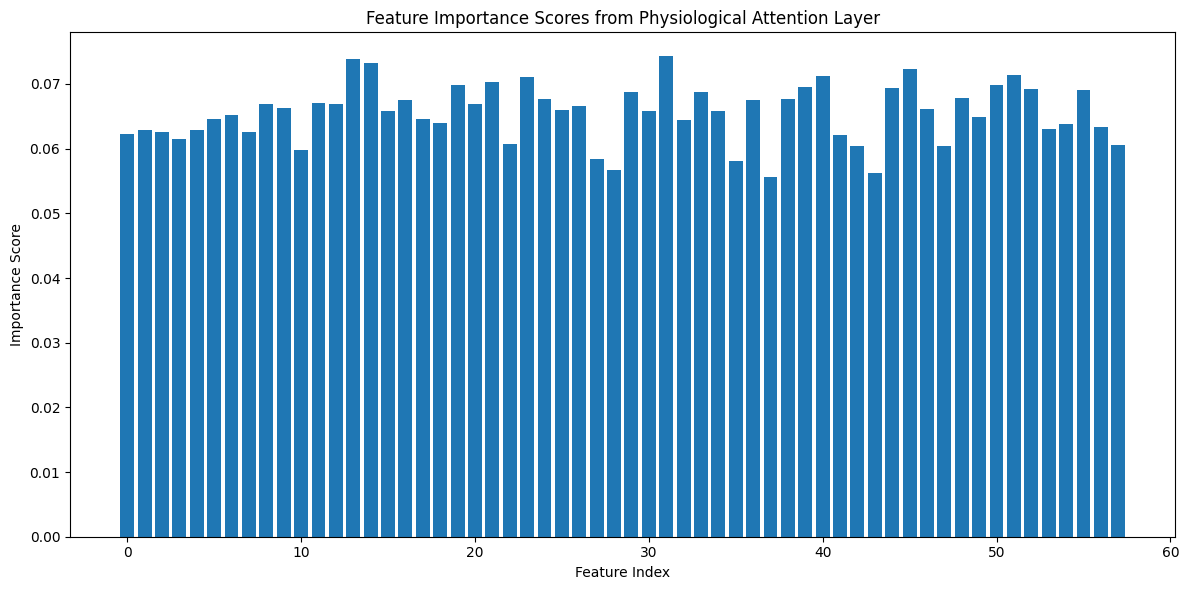

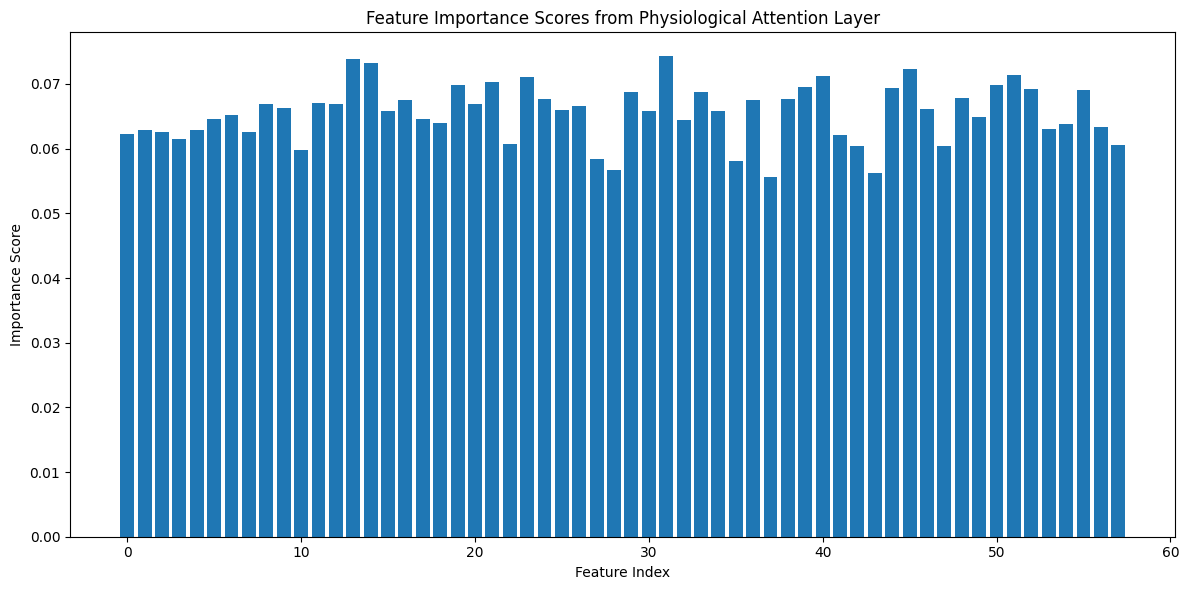

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Attention layer weights
weights = model.phys_attention.attention[2].weight.detach().cpu().numpy()

# Importance score
importance_scores = np.mean(
    np.abs(weights),
    axis=0
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.title(
    "Feature Importance Scores from Physiological Attention Layer"
)

plt.tight_layout()
plt.show()
fig = plt.figure(figsize=(12,6))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.xlabel("Feature Index")
plt.ylabel("Importance Score")

plt.title(
    "Feature Importance Scores from Physiological Attention Layer"
)

plt.tight_layout()

fig.savefig(
    "Feature_Importance_Scores.jpg",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

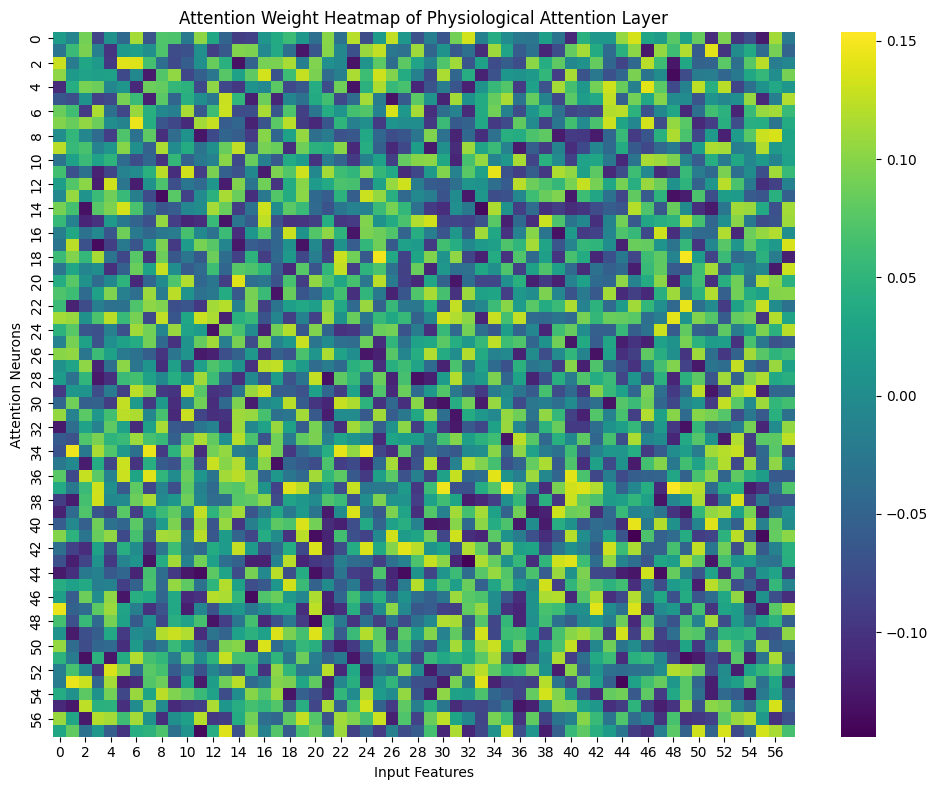

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

weights = model.phys_attention.attention[2].weight.detach().cpu().numpy()

plt.figure(figsize=(10,8))

sns.heatmap(
    weights,
    cmap="viridis"
)

plt.title(
    "Attention Weight Heatmap of Physiological Attention Layer"
)

plt.xlabel("Input Features")
plt.ylabel("Attention Neurons")

plt.tight_layout()

plt.savefig(
    "Attention_Weight_Heatmap.jpg",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.savefig(...)
plt.show()

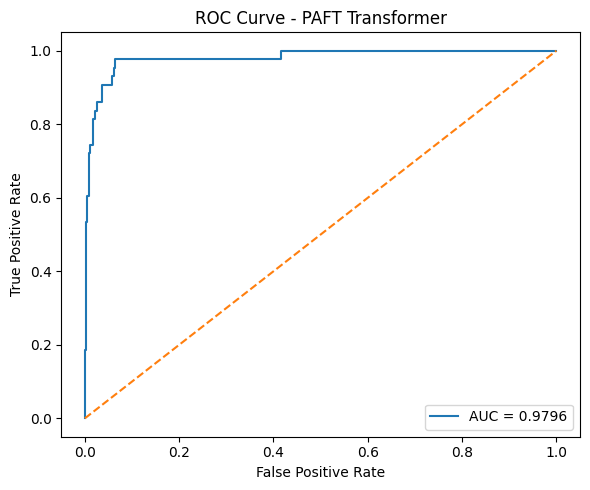

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PAFT Transformer")
plt.legend()

plt.tight_layout()

plt.savefig(
    "ROC_Curve.jpg",
    dpi=300,
    bbox_inches='tight'
)

plt.show()